# Ordinal Logistic Loss (Cumulative Link Model)

This loss function handles ordinal relationships by modeling the cumulative probability.

Note: the following code and explination are sourced heavily from:
https://hippocampus-garden.com/ordinal_regression/#:~:text=In%20this%20post%2C%20we%20covered%20three%20approaches,and%20multiple%20thresholds%20to%20model%20cumulative%20probabilities

The cumulative probability is modeled as

$P(y <= k) = \sigma(a_k - z)$

The probability of each class is derived as follows, using $P(y = 1)$ as an example, and then generalizing.

$P(y = 1) = \sigma(a_1 - z) - \sigma(a_0 - z)$

Generalizing to:
$P(y = k) = \sigma(a_k - z) - \sigma(a_{k-1} - z), k = 1,...,K - 1$
$P(y = K - 1) = 1 - \sigma(a_{K - 2} - z)$

These probabilities are used to compute the ordinal logistic loss as the negative log likelihood:

$L = - \sum_i logP(y = y_i)$

In [2]:
!git clone https://github.com/nedcut/ML-final.git
%cd ML-final
!pip install coral_pytorch

import random
from pathlib import Path
import pandas as pd
import torch
from torch import nn
import torch.nn.functional as F
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
from coral_pytorch.losses import corn_loss
from coral_pytorch.dataset import corn_label_from_logits


SEED = 42
PROJECT_ROOT = Path.cwd()

DATA_PATH = PROJECT_ROOT / "data/processed/vt_condition_weather_aligned.csv"
TEST_SEASONS = 4
N_EPOCHS = 500
LEARNING_RATE = 0.05

scaler = StandardScaler()

random.seed(SEED)
torch.manual_seed(SEED)

df = pd.read_csv(DATA_PATH)

Cloning into 'ML-final'...
remote: Enumerating objects: 109, done.
remote: Counting objects: 100% (109/109), done.
remote: Compressing objects: 100% (80/80), done.
remote: Total 109 (delta 33), reused 56 (delta 16), pack-reused 0 (from 0)
Receiving objects: 100% (109/109), 11.51 MiB | 4.33 MiB/s, done.
Resolving deltas: 100% (33/33), done.
/content/ML-final


## Choose features and split by season

Splitting training/testing sequentially, not randomly, preserving time series structure.

In [3]:
class_names = ["A", "B", "C", "D"]
class_to_ix = {name: i for i, name in enumerate(class_names)}

season_order = sorted(df["season_start_year"].unique())
test_years = season_order[-TEST_SEASONS:]
train_years = season_order[:-TEST_SEASONS]

train_df = df[df["season_start_year"].isin(train_years)].copy()
test_df = df[df["season_start_year"].isin(test_years)].copy()

feature_cols = [
    col for col in df.columns
    if (col.startswith("best_")) #or col.startswith("avg_"))
    and pd.api.types.is_numeric_dtype(df[col])
    and "weather_days_observed" not in col
    and "location_count" not in col
]

print(feature_cols)

print(f"train seasons: {train_df['season'].min()} through {train_df['season'].max()} ({len(train_df)} rows)")
print(f"test seasons:  {test_df['season'].min()} through {test_df['season'].max()} ({len(test_df)} rows)")
print(f"features: {len(feature_cols)}")
feature_cols[:8]


X_train_raw = scaler.fit_transform(train_df[feature_cols].values)
X_test_raw  = scaler.transform(test_df[feature_cols].values)

X_train = torch.tensor(X_train_raw, dtype=torch.float32)
X_test = torch.tensor(X_test_raw, dtype=torch.float32)

#Will make response tensors in evaluation loop
y_train = train_df["grade"].map(class_to_ix).values
y_test = test_df["grade"].map(class_to_ix).values

['best_hours_above_freezing_sum_7d', 'best_hours_above_freezing_mean_7d', 'best_hours_above_freezing_max_7d', 'best_hours_above_freezing_label_day', 'best_temperature_mean_7d', 'best_temperature_min_7d', 'best_temperature_max_7d', 'best_temperature_label_day', 'best_humidity_mean_7d', 'best_humidity_min_7d', 'best_humidity_max_7d', 'best_humidity_label_day', 'best_snow_depth_mean_7d', 'best_snow_depth_min_7d', 'best_snow_depth_max_7d', 'best_snow_depth_label_day', 'best_wind_speed_mean_7d', 'best_wind_speed_min_7d', 'best_wind_speed_max_7d', 'best_wind_speed_label_day', 'best_rain_sum_7d', 'best_rain_max_7d', 'best_rain_label_day', 'best_snowfall_sum_7d', 'best_snowfall_max_7d', 'best_snowfall_label_day']
train seasons: 1999-00 through 2020-21 (627 rows)
test seasons:  2021-22 through 2024-25 (114 rows)
features: 26


/tmp/ipykernel_2748/2477277628.py:68: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(y, dtype=torch.long)


epoch 0: loss=-0.2107
epoch 100: loss=-0.5375
epoch 200: loss=-0.5905
epoch 300: loss=-0.6017
epoch 400: loss=-0.6079


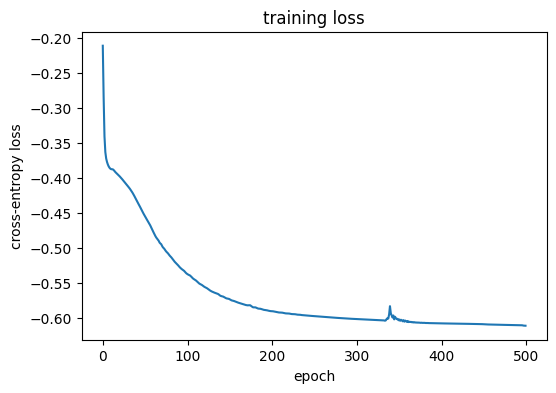

train accuracy: 0.887
test accuracy:  0.588
within one on training: 0.970
within one on testing:  0.877


/tmp/ipykernel_2748/2477277628.py:145: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(y_train, dtype=torch.long)
/tmp/ipykernel_2748/2477277628.py:146: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_test = torch.tensor(y_test, dtype=torch.long)


,A,B,C,D
A,14,4,4,1
B,1,6,3,7
C,2,8,3,15
D,0,0,2,44


In [5]:
### Ordinal Logistic Loss
class OrdinalLogisticModel(nn.Module):
  def __init__(self, n_features, hidden_dim, n_classes):
    super().__init__()
    #Ordinal NN relies on probababilities, here:
    #P(rating > D)?
    #P(rating > C)?
    #P(rating > B)? ---> if all true, implies A,
    #so only need 3 classes in final layer, or # classes - 1
    self.layer1 = nn.Linear(n_features, hidden_dim)
    self.layer2 = nn.Linear(hidden_dim, 1)
    self.raw_alpha = nn.Parameter(torch.zeros(n_classes - 1))

  def forward(self, X):
    X = torch.relu(self.layer1(X))
    X = self.layer2(X).squeeze(-1)
    alpha_sorted = torch.cumsum(F.softplus(self.raw_alpha), dim=0)
    return X, alpha_sorted

class OrdinalLogLoss(nn.Module):
  def __init__(self, num_classes):
    super().__init__()
    self.num_classes = num_classes

  def forward(self, inputs, target):
    z, alpha = inputs
    K = self.num_classes
    batch_size = z.size(0)

    #P(Y= 0)
    p_y0 = torch.sigmoid(alpha[0] - z)
    #P(Y=K-1), last probability
    p_yK_1 = 1.0 - torch.sigmoid(alpha[-1] - z)

    #Ks in the middle
    if K > 2:
      sig_all = torch.sigmoid(alpha.unsqueeze(1) - z.unsqueeze(0)) #A(K-1, batch size)
      #p_middle[k] = sigma(alpha_k - z) - sigma(alpha{k-1} - z)
      p_mid = sig_all[1:] - sig_all[:-1] #(K-2, batch_size)
      p_mid = p_mid.transpose(0,1) #(batch_size, K-2)
    else:
      p_mid = None
    p = torch.empty_like(z)

    mask0 = (target == 0)
    p[mask0] = p_y0[mask0]

    maskK_1 = (target == (K-1))
    p[maskK_1] = p_yK_1[maskK_1]

    if K > 2:
      #not first or last element
      mask_mid = ~(mask0 | maskK_1)
      if mask_mid.any():
        idx = target[mask_mid] - 1
        rowwise = p_mid[mask_mid]
        idx_2d = idx.unsqueeze(1)
        p_vals = torch.gather(rowwise, 1, idx_2d).squeeze(1)
        p[mask_mid] = p_vals

    #-log likelihood
    #random error
    epsilon = 13-12
    nll = -torch.log(p + epsilon)
    return nll.mean()

def train_ol_model(model, X, y, n_classes, epochs=N_EPOCHS, learning_rate=LEARNING_RATE):
    y = torch.tensor(y, dtype=torch.long)
    opt = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = OrdinalLogLoss(num_classes = n_classes)
    losses = []

    for epoch in range(epochs):
        opt.zero_grad()
        scores = model(X)
        loss = criterion(scores, y)
        losses.append(loss.item())
        loss.backward()
        opt.step()
        if epoch % 100 == 0:
            print(f"epoch {epoch}: loss={loss.item():.4f}")
    return losses

def predict(model, X):
  with torch.no_grad():
    z_test, alpha_test = model.forward(X)
    #print("here")
    #print(z_test)
    # p(Y=0) = σ(alpha_0 - z)
    p_y0 = torch.sigmoid(alpha_test[0] - z_test).unsqueeze(1)
    # p(Y=2) = 1 - σ(alpha_1 - z)
    p_y2 = (1.0 - torch.sigmoid(alpha_test[-1] - z_test)).unsqueeze(1)
    # p(Y=1) = middle probability
    if alpha_test.size(0) > 1:
      sig_all = torch.sigmoid(alpha_test.unsqueeze(1) - z_test.unsqueeze(0))  # (2, N)
      p_mid = (sig_all[1:] - sig_all[:-1]).transpose(0, 1)  # (N, 1)
    else:
      p_mid = None

    if p_mid is None:
      # For binary classification only
      p_all = torch.cat([p_y0, p_y2], dim=1)
    else:
      p_all = torch.cat([p_y0, p_mid, p_y2], dim=1)  # (N, 3)
    pred_label = torch.argmax(p_all, dim=1)
    #print(pred_label)
    return pred_label

def confusion_matrix(y_true, y_pred, n_classes):
    matrix = torch.zeros(n_classes, n_classes, dtype=torch.int64)
    for actual, pred in zip(y_true, y_pred):
        matrix[actual, pred] += 1
    return matrix


def metrics_table(matrix, class_names):
    rows = []
    for i, name in enumerate(class_names):
        tp = matrix[i, i].item()
        predicted = matrix[:, i].sum().item()
        actual = matrix[i, :].sum().item()
        precision = tp / predicted if predicted else 0.0
        recall = tp / actual if actual else 0.0
        rows.append({
            "class": name,
            "precision": precision,
            "recall": recall,
            "actual_count": actual,
            "predicted_count": predicted,
        })
    return pd.DataFrame(rows)

model = OrdinalLogisticModel(n_features=X_train.shape[1], hidden_dim = 16, n_classes=len(class_names))
losses = train_ol_model(model, X_train, y_train, n_classes = len(class_names))


fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(losses)
ax.set(xlabel="epoch", ylabel="cross-entropy loss", title="training loss")
plt.show()

test_preds = predict(model, X_test)
train_preds = predict(model, X_train)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)


train_acc = (train_preds == y_train).float().mean().item()
test_acc = (test_preds == y_test).float().mean().item()

#testing % of values that are == to actual or neighboring actual
train_diff = (train_preds - y_train).abs()
within_one_train = ((train_diff == 0) | (train_diff == 1)).float().mean().item()

test_diff = (test_preds - y_test).abs()
within_one_test = ((test_diff == 0) | (test_diff == 1)).float().mean().item()

matrix = confusion_matrix(y_test, test_preds, len(class_names))
confusion = pd.DataFrame(matrix.numpy(), index=class_names, columns=class_names)

print(f"train accuracy: {train_acc:.3f}")
print(f"test accuracy:  {test_acc:.3f}")
print(f"within one on training: {within_one_train:.3f}")
print(f"within one on testing:  {within_one_test:.3f}")
confusion

